In [2]:
import numpy as np
import pandas as pd
import time
import os
import sys
import glob
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from collections import Counter
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import importlib
import ast

import Functions_HighValsCheck
importlib.reload(Functions_HighValsCheck)

from Functions_HighValsCheck import (find_problematic_catchment_em_combos_complex, check_extremes_across_combos,
                                    plot_surrounding_ts_new, plot_n_peaks, compare_bc_nonbc_timeseries)
# ── Config ────────────────────────────────────────────────────────────────────
from config import RAINFALL_CSV_DIR, CATCHMENT_LOOKUP_DICT, OUT_DIR, CATCHMENTS, ENSEMBLE_MEMBERS 

# ── Define which catchments to run ────────────────────────────────────────────────────────────────────
all_catchments = set(CATCHMENT_LOOKUP_DICT.keys())

In [45]:
def compare_bc_nonbc_timeseries(rainfall_cube_dir_bc, rainfall_cube_dir_nonbc, catchment_num, ens_num):
    '''
    For the peak event in the catchment
    '''
    catchment_name = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
    boundary_gdf   = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
    CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]

    # ── Mask setup ────────────────────────────────────────────────────────────
    full_rain_cube = get_rainfall_cube_subsection(
        2015, '01',
        f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/01/",
        1, 2)
    FULL_MASK_2D = mask_cube_with_catchment_full_grid(
        full_rain_cube[0], CATCHMENT_POLY, method='center_point')

    # ── Find peak event ───────────────────────────────────────────────────────
    rainfall_events = pd.read_csv(RAINFALL_CSV_DIR + f"{catchment_name}_{ens_num}_full_events_with_event_nums.csv")
    rainfall_events['event_num']  = range(1, len(rainfall_events) + 1)
    rainfall_events['hydro_year'] = rainfall_events['start_year'].where(
        rainfall_events['start_month'] != 12,
        rainfall_events['start_year'] + 1)

#     peak_event_row = rainfall_events.nlargest(1, 'peaks').iloc[0]
    peak_event_row = rainfall_events[rainfall_events['event_num']==232].iloc[0]
    year           = int(peak_event_row['hydro_year'])
    event_num      = int(peak_event_row['event_num'])
    event_details  = get_rainfall_event_details(rainfall_events, event_num)

    start_idx = event_details['start_idx']
    stop_idx  = event_details['stop_idx']
    # start_time = pd.to_datetime(event_details['start_time'])  # <-- assumes this exists
    start_time = pd.Timestamp(year=event_details['start_year'],  month=event_details['start_month'],day=event_details['start_day'], hour=event_details['start_hour'])
        
    # ── Load both cubes ───────────────────────────────────────────────────────
    def load_spatial_mean(cube_dir, bc):
        loader = get_rainfall_cube_subsection if bc else get_rainfall_cube_subsection_notbc
        cube   = loader(year, ens_num, cube_dir, start_idx, stop_idx)
        cube.data = np.where(FULL_MASK_2D, cube.data, np.nan)
        return np.nanmean(cube.data.reshape(cube.shape[0], -1), axis=1)

    vals_bc    = load_spatial_mean(rainfall_cube_dir_bc,    bc=True)
    vals_nonbc = load_spatial_mean(rainfall_cube_dir_nonbc, bc=False)

    # ── Build datetime index ──────────────────────────────────────────────────
    n_steps = len(vals_bc)
    time_index = pd.date_range(start=start_time, periods=n_steps, freq='H')  # adjust freq if needed

    # ── Build tidy dataframe ──────────────────────────────────────────────────
    df = pd.DataFrame({
        'datetime': time_index,
        'bc': vals_bc,
        'non_bc': vals_nonbc })
    return df

In [46]:
catchment_num ='105'
catchment_name = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
ens_num = '15'

rainfall_cube_dir_bc = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens_num}/"
rainfall_cube_dir_notbc = f"/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Precipitation/Hourly/5km/Ens_{ens_num}/"
df =compare_bc_nonbc_timeseries(rainfall_cube_dir_bc, rainfall_cube_dir_notbc, catchment_num, ens_num)
# df['ratio'] = df['bc']/df['non_bc']

/tmp/ipykernel_1389311/562122029.py:47: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start=start_time, periods=n_steps, freq='H')  # adjust freq if needed


422

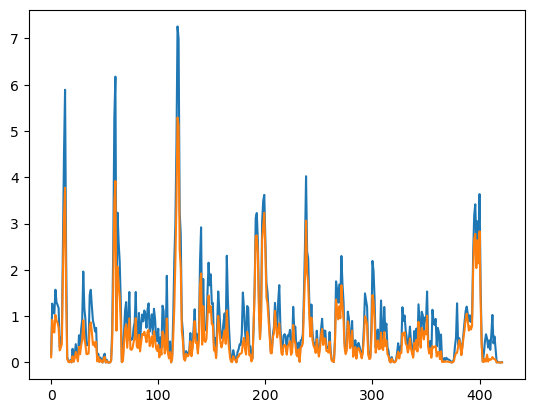

In [47]:
plt.plot(df['bc'])
plt.plot(df['non_bc'])
len(df)

In [44]:
rainfall_events = pd.read_csv(RAINFALL_CSV_DIR + f"{catchment_name}_{ens_num}_full_events_with_event_nums.csv")
rainfall_events.sort_values(by = 'event_durations')


,start_indices,stop_indices,event_durations,peaks,start_year,start_month,start_day,start_hour,start_time,stop_time,start_time_seconds,stop_time_seconds,event_vol,max_extent,acc_total,acc_3hr,acc_6hr,acc_12hr,acc_24hr,event_num
153,662,670,8,38.06118,2043,12,28,13,639301.5,639309.5,2301485400,2301514200,144.881063,4,144.881063,144.864551,144.875432,NaN,NaN,154
379,393,401,8,44.01660,2066,12,17,8,837752.5,837760.5,3015909000,3015937800,98.763997,4,98.763997,98.763323,98.763835,NaN,NaN,380
294,7530,7538,8,41.85017,2059,10,14,17,775769.5,775777.5,2792770200,2792799000,91.648666,2,91.648666,72.830220,91.024905,NaN,NaN,295
288,915,923,8,97.86480,2059,1,9,2,769154.5,769162.5,2768956200,2768985000,182.096704,1,182.096704,182.094368,182.095151,NaN,NaN,289
116,346,355,9,70.05415,2033,12,15,9,552585.5,552594.5,1989307800,1989340200,842.087712,79,842.087712,826.578260,837.119182,NaN,NaN,117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,7901,8127,226,38.37654,2045,10,30,4,655180.5,655406.5,2358649800,2359463400,31862.442625,120,31862.442625,2177.309100,4170.627700,6572.30750,7669.384944,165
482,8586,8818,232,52.61754,2073,11,28,17,897785.5,898017.5,3232027800,3232863000,13580.479458,91,13580.479458,1294.801000,1676.102010,3062.72889,3828.961372,483
421,7423,7662,239,48.89526,2069,10,10,6,862062.5,862301.5,3103425000,3104285400,21088.347284,87,21088.347284,1374.610100,2615.342300,4029.53547,4397.789750,422
159,848,1101,253,140.80000,2045,1,6,7,648127.5,648380.5,2333259000,2334169800,20803.059304,104,20803.059304,1449.858700,2410.769000,3890.56190,4580.620826,160


In [26]:
from config import *
from functions import get_rainfall_event_details, mask_cube_with_catchment_full_grid, subset_cube_to_bbox
from functions_stage2 import (get_rainfall_cube_subsection, get_exceedance_summary, find_max_precip_location_new, get_data_at_peak_cell,
                                find_temporal_profile_new)




import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import iris.quickplot as qplt
import iris.plot as iplt
import iris
import time
import cftime
import sys
import traceback

sys.path.append("../")

from config import *
from functions import get_rainfall_event_details, mask_cube_with_catchment_full_grid, subset_cube_to_bbox
from functions_stage2 import (get_rainfall_cube_subsection, get_exceedance_summary, find_max_precip_location_new, get_data_at_peak_cell,
                                find_temporal_profile_new)

def plot_n_peaks(rainfall_cube_dir, ens_num, catchment_num, n = 9 , bc = True):
    
    # Get data for the catchment
    catchment_name  = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
    boundary_gdf    = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
    CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]
    # Make sure both are in the same CRS
    #catchment_gdf = gpd.GeoDataFrame(geometry=[CATCHMENT_POLY], crs=waterbodies_df.crs)
    # Spatial join — keeps only waterbodies that fall within the catchment
    #waterbodies_in_catchment = gpd.sjoin( waterbodies_df,  catchment_gdf,  how='inner', predicate='within')

    # ───────────────────────────────────────────────── 
    # Create a mask for this catchment (over whole UK)
    # Create a version of it over the area filtered to the catchment
    # These are used later
    # ───────────────────────────────────────────────── 
    full_rain_cube = get_rainfall_cube_subsection(2015, '01', f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/01/", 1, 2) #any year, any ensemble member
    FULL_MASK_2D   = mask_cube_with_catchment_full_grid(full_rain_cube[0], CATCHMENT_POLY, method='center_point')
    year_cube, mask_x_offset, mask_y_offset = subset_cube_to_bbox(full_rain_cube, CATCHMENT_POLY, buffer=0)
    ny_sub = year_cube.shape[1]
    nx_sub = year_cube.shape[2]
    mask_2d_sub = FULL_MASK_2D[mask_y_offset:mask_y_offset + ny_sub, 
                                mask_x_offset:mask_x_offset + nx_sub]

    # ───────────────────────────────────────────────── 
    # Loop over EMs (wrap in try/pass to deal with errors from mismatch of max precip)
    # ───────────────────────────────────────────────── 
    # Read in the csv with event details for this catchment/ensemble member
    rainfall_events  = pd.read_csv(RAINFALL_CSV_DIR + f"{catchment_name}_{ens_num}_full_events_with_event_nums.csv")
    rainfall_events['event_num']  = range(1, len(rainfall_events) + 1)
    rainfall_events['hydro_year'] = rainfall_events['start_year'].where(rainfall_events['start_month'] != 12,
            rainfall_events['start_year'] + 1)
    
    # Create cached version of event details, for all events
    event_details_cache = {
        ev: get_rainfall_event_details(rainfall_events, ev)
        for ev in rainfall_events['event_num']}

    top10_events = rainfall_events.nlargest(n, 'peaks')

    i=0
    fig, axs = plt.subplots(ncols=3, nrows =int(n/3), figsize=(10,10), subplot_kw={'projection': ccrs.OSGB()})
    axs=axs.flatten()
    for year, events_in_year in top10_events.groupby('hydro_year'):
        begin_time = time.time()

        for row in events_in_year.itertuples():
            # print(f"Peak precip is {row.peaks}")
            # Get the event details from the cache
            event_num     = int(row.event_num)
            event_details = event_details_cache[event_num]

            # Get a portion of the cube, over the catchment, between the times when the maximum happened
            if bc ==True:
                year_cube = get_rainfall_cube_subsection(year, ens_num, rainfall_cube_dir, 
                                                 event_details['start_idx']-1, event_details['stop_idx'])
            else:
                year_cube = get_rainfall_cube_subsection_notbc(year, ens_num, rainfall_cube_dir, 
                                                     event_details['start_idx']-1, event_details['stop_idx'])
            
            year_cube.data = np.where(FULL_MASK_2D, year_cube.data, np.nan)
            year_cube, x_offset, y_offset = subset_cube_to_bbox(year_cube, CATCHMENT_POLY, buffer=0)
            # Extract the times for this subset
            time_coord  = year_cube.coord('time')

            time_from_cube   = time_coord.units.num2date(np.floor(time_coord.points[0]))
            time_from_csv = cftime.Datetime360Day(event_details['yr'], event_details['month'], event_details['day'], event_details['hour'])
            times_the_same = time_from_cube == time_from_csv

            # Find the location of the max precipitation value
            # This masks out all cells not inside the catchment
            this_event_results = find_max_precip_location_new(
                year_cube, event_details['start_idx'], event_details['stop_idx'],
                x_offset=x_offset, y_offset=y_offset, mask_2d=mask_2d_sub)
            this_event_results['max_precip_from_csv']  = event_details['max_precip_from_csv']

            # Get 1D cube, just at the location of the peak
            #rainfall_at_peak  = get_data_at_peak_cell(year_cube, this_event_results, 'x_idx', 'y_idx')
            # Extract various temporal profile results
            #temp_profile_dict = find_temporal_profile_new(rainfall_at_peak, this_event_results, plot=True)

            if not times_the_same:
                this_event_results['time_mismatch'] = True
                print("TIME MISMACH")
            else:
                this_event_results['time_mismatch'] = False

            # Check whether the maximum precipitation matches the values in the input csv
#             if not math.isclose(float(np.float32(this_event_results['max_precip'])), 
#                                  float(np.float32(this_event_results['max_precip_from_csv'])),
#                                  abs_tol=0.001):
#                 print(f"MISMATCH — ens={ens_num}, year={year}, event={event_num}")
#                 print(f"  cube: {this_event_results['max_precip']:.8f}")
#                 print(f"  csv:  {this_event_results['max_precip_from_csv']:.8f}")
#                 this_event_results['mismatch'] = True
#             else:
#                 this_event_results['mismatch'] = False            

            max_time_idx = np.unravel_index(np.nanargmax(year_cube.data), year_cube.data.shape)[0]
            qplt.pcolormesh(year_cube[max_time_idx,:,:], axes=axs[i], cmap='YlGn', edgecolor='none', linewidth=0.5)
            axs[i].coastlines(resolution='10m', color='red')
            #axs[i].add_geometries(waterbodies_in_catchment.geometry, crs=ccrs.OSGB(), facecolor='cornflowerblue', edgecolor='steelblue', linewidth=0.5)
            axs[i].add_geometries([CATCHMENT_POLY], crs=ccrs.OSGB(), facecolor='none', edgecolor='black', linewidth=1.5)
            rounded = round(float(np.nanmax(year_cube[max_time_idx,:,:].data)), 1)
            axs[i].set_title(f"Peak precip is {rounded} and not {round(row.peaks,1)}")
            i=i+1
    fig.tight_layout()      



def get_rainfall_cube_subsection_notbc(yr, ENS_NUM, RAINFALLDIR, start_idx=None, stop_idx=None):

    HOURS_PER_MONTH = 30 * 24  # 720 — constant for this 360-day calendar dataset

    # ── Build the full ordered list of monthly files ───────────────────────────
    # Each entry records the file path and the global index range it covers,
    # so we can later identify which files overlap with [start_idx, stop_idx].
    # 'global_start' is inclusive, 'global_end' is exclusive (half-open interval).
    all_files  = []
    cumulative = 0  # running total of timesteps, used to assign global index ranges

    # File 0: December of the previous calendar year
    # This is always the first month of the hydrological year (indices 0–719)
    all_files.append({
        'path':         f"{RAINFALLDIR}pr_rcp85_land-cpm_uk_5km_{ENS_NUM}_1hr_{yr-1}1201-{yr-1}1230.nc",
        'global_start': cumulative,
        'global_end':   cumulative + HOURS_PER_MONTH
    })
    cumulative += HOURS_PER_MONTH

    # Files 1–11: January through November of the target year (indices 720–8639)
    # Note: we stop at month 11 (November) because December belongs to the
    # *next* hydrological year
    for m in range(1, 12):
        all_files.append({
            'path':         f"{RAINFALLDIR}pr_rcp85_land-cpm_uk_5km_{ENS_NUM}_1hr_{yr}{m:02d}01-{yr}{m:02d}30.nc",
            'global_start': cumulative,
            'global_end':   cumulative + HOURS_PER_MONTH
        })
        cumulative += HOURS_PER_MONTH

    # File 12: December of the target year (indices 8640–9359)
    # This file is ONLY needed for edge-case events that start in late November
    # and whose stop_idx bleeds past the end of the hydrological year (> 8639).
    # Including it here costs nothing if it isn't needed — the filter below will
    # simply not select it.
    all_files.append({
        'path':         f"{RAINFALLDIR}pr_rcp85_land-cpm_uk_5km_{ENS_NUM}_1hr_{yr}1201-{yr}1230.nc",
        'global_start': cumulative,
        'global_end':   cumulative + HOURS_PER_MONTH
    })

    # ── Select only the files that overlap with [start_idx, stop_idx] ─────────
    # A file overlaps the requested window if:
    #   - it ends after the window starts (global_end > start_idx), AND
    #   - it starts before the window ends (global_start < stop_idx)
    # This is standard half-open interval intersection logic.
    # For a typical event this reduces 13 file loads down to 1 or 2.
    if start_idx is not None and stop_idx is not None:
        needed = [f for f in all_files
                  if f['global_end'] > start_idx and f['global_start'] < stop_idx]
    else:
        # No indices provided — load the full hydrological year
        needed = all_files

    # ── Warn if the overflow December file is being used ──────────────────────
    # This is an unusual case and worth flagging so we know it's happening
#     if needed and needed[-1]['path'].endswith(f"{yr}1201-{yr}1230.nc"):
#         print(f"  WARNING: event bleeds into Dec {yr} (stop_idx={stop_idx} > 8639) — loading overflow file")

    # ── Load only the needed files and concatenate into a single cube ─────────
    monthly_cubes = iris.cube.CubeList()
    for f in needed:
        cube = iris.load(f['path'])[0][0,:,:]  # [1] selects the rainfall variable from the file
        cube.attributes = {}            # clear attributes so concatenation doesn't fail
                                        # on mismatched metadata between monthly files
        monthly_cubes.append(cube)
    #year_cube = monthly_cubes.concatenate_cube()
    year_cube = iris.cube.CubeList(monthly_cubes).concatenate_cube()

    # ── Slice the concatenated cube to the exact requested window ─────────────
    # The indices stored in start_idx/stop_idx are in the global hydro-year
    # index space (0 = start of Dec(yr-1)). But after loading only a subset
    # of files, the cube's own time axis starts at the beginning of the first
    # *loaded* file, not at 0. So we subtract that file's global_start ('offset')
    # to convert global indices into local indices within the loaded cube.
    if start_idx is not None and stop_idx is not None:
        offset = needed[0]['global_start']
        return year_cube[start_idx - offset:stop_idx - offset, :, :]

    return year_cube

def find_problematic_catchment_em_combos_complex (all_catchments, THRESHOLD, CATCHMENTS, CATCHMENT_LOOKUP_DICT, ENSEMBLE_MEMBERS, RAINFALL_CSV_DIR):
    OUTPUT_DIR      = "problematic_catchment_outputs/"
    PLOT_DIR        = os.path.join(OUTPUT_DIR, "plots/")
    WINDOW          = 10

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    os.makedirs(PLOT_DIR,   exist_ok=True)

    # ── Main results collectors ───────────────────────────────────────────────────
    problematic_catchment_names = []
    problematic_catchment_nums  = []
    results                     = []

    for catchment_num in all_catchments:
        catchment_name  = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
        boundary_gdf    = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
        CATCHMENT_POLY  = boundary_gdf.geometry.iloc[0]

        for ens_num in ENSEMBLE_MEMBERS:
            # print(f"Processing catchment {catchment_num} ({catchment_name}), EM{ens_num}...")

            RAINFALL_CUBE_DIR = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens_num}/"

            # ── 1. Load event CSV (same as before) ───────────────────────────────
            rainfall_events = pd.read_csv(
                RAINFALL_CSV_DIR + f"{catchment_name}_{ens_num}_full_events_with_event_nums.csv")
            
            rainfall_events['event_num']  = range(1, len(rainfall_events) + 1)
            rainfall_events['hydro_year'] = rainfall_events['start_year'].where(
                rainfall_events['start_month'] != 12,
                rainfall_events['start_year'] + 1)

#             peak_max      = rainfall_events['peaks'].max()
#             n_problematic = len(rainfall_events[rainfall_events['peaks'] > THRESHOLD])
#             n_total       = len(rainfall_events)

#             if peak_max <= THRESHOLD:
#                 continue  # skip — nothing to do for this catchment/ens combo

            problematic_events = rainfall_events[rainfall_events['peaks'] > THRESHOLD]
            n_problematic      = len(problematic_events)
            n_total            = len(rainfall_events)
            peak_max           = rainfall_events['peaks'].max()
            problematic_event_nums = problematic_events['event_num'].tolist()

            if n_problematic == 0:
                continue

            # ── 2. Flag as problematic ────────────────────────────────────────────
            problematic_catchment_nums.append(catchment_num)
            problematic_catchment_names.append(catchment_name)

            # ── 3. Load cube and mask (mirrors plot_surrounding_ts logic) ─────────
            try:
                peak_event_row = rainfall_events.nlargest(1, 'peaks').iloc[0]
                year           = int(peak_event_row['hydro_year'])
                event_num      = int(peak_event_row['event_num'])
                event_details  = get_rainfall_event_details(rainfall_events, event_num)

                full_rain_cube = get_rainfall_cube_subsection(
                    year, ens_num, RAINFALL_CUBE_DIR,
                    event_details['start_idx'] - 1,
                    event_details['stop_idx']
                )
                FULL_MASK_2D = mask_cube_with_catchment_full_grid(
                    full_rain_cube[0], CATCHMENT_POLY, method='center_point'
                )
                BUFFER    = 3
                year_cube = get_rainfall_cube_subsection(
                    year, ens_num, RAINFALL_CUBE_DIR,
                    event_details['start_idx'] - 1 - BUFFER,
                    event_details['stop_idx']  + BUFFER
                )
                year_cube.data        = np.where(FULL_MASK_2D, year_cube.data, np.nan)
                year_cube, x_off, y_off = subset_cube_to_bbox(year_cube, CATCHMENT_POLY, buffer=0)

                max_time_idx = np.unravel_index(
                    np.nanargmax(year_cube.data), year_cube.data.shape
                )[0]

                # ── 4. Run exceedance summary ─────────────────────────────────────
                exceedance_summary, window_indices = get_exceedance_summary(
                    year_cube, max_time_idx, threshold=THRESHOLD, window=WINDOW
                )

                # ── 5. Save persistence map plot ──────────────────────────────────
                fig, ax = plt.subplots(
                    figsize=(6, 5), subplot_kw={'projection': ccrs.OSGB()}
                )
                persist_cube      = year_cube[0, :, :].copy()
                persist_cube.data = exceedance_summary["timesteps_per_cell_2d"].astype(float)
                persist_cube.data[persist_cube.data == 0] = np.nan

                iplt.pcolormesh(persist_cube, axes=ax, cmap='OrRd', vmin=1, vmax=WINDOW)
                ax.coastlines(resolution='10m', color='grey')
                ax.add_geometries(
                    [CATCHMENT_POLY], crs=ccrs.OSGB(),
                    facecolor='none', edgecolor='black', linewidth=1.5
                )
                ax.set_title(
                    f"Catchment {catchment_num} ({catchment_name}) — EM{ens_num}\n"
                    f"N timesteps (of ±{WINDOW}) where cell > {THRESHOLD}mm"
                )
                plt.colorbar(ax.collections[0], ax=ax, label="N timesteps exceeding threshold")
                fig.tight_layout()

                plot_path = os.path.join(
                    PLOT_DIR, f"catchment_{catchment_num}_{catchment_name}_EM{ens_num}_persistence.png"
                )
                fig.savefig(plot_path, dpi=150, bbox_inches='tight')
                plt.close(fig)

            except Exception as e:
                print(f"  WARNING: cube loading failed for {catchment_name} EM{ens_num}: {e}")
                exceedance_summary = {k: None for k in [
                    "n_timesteps_any_exceedance", "n_cells_any_exceedance",
                    "total_exceedances", "max_cells_in_one_timestep", "max_timesteps_one_cell"
                ]}

            # ── 6. Append to results ──────────────────────────────────────────────
            results.append({
                "Catchment No.":               catchment_num,
                "Catchment Name":              catchment_name,
                "Ensemble Member":             ens_num,
                "Highest Peak (mm)":           round(peak_max, 2),
                "Events > 150mm":              n_problematic,
                "Total Events":                n_total,
                "% Problematic":               round(100 * n_problematic / n_total, 1),
                "Problematic Event Nums": problematic_event_nums,
                # Exceedance metrics
                "Timesteps w/ any exceedance": exceedance_summary["n_timesteps_any_exceedance"],
                "Cells w/ any exceedance":     exceedance_summary["n_cells_any_exceedance"],
                "Total (t,cell) exceedances":  exceedance_summary["total_exceedances"],
                "Max cells in 1 timestep":     exceedance_summary["max_cells_in_one_timestep"],
                "Max timesteps for 1 cell":    exceedance_summary["max_timesteps_one_cell"],
            })

    # ── 7. Save summary table ─────────────────────────────────────────────────────
    results_df = pd.DataFrame(results).sort_values(
        ["Catchment No.", "Ensemble Member"]
    ).reset_index(drop=True)

    results_df.to_csv( os.path.join(OUTPUT_DIR, "problematic_catchments.csv"),  index=False)
    # results_df.to_excel(os.path.join(OUTPUT_DIR, "problematic_catchments.xlsx"), index=False)

    print(f"\nDone. {len(results_df)} problematic combinations across "
          f"{results_df['Catchment No.'].nunique()} catchments.")
    print(f"Outputs saved to: {OUTPUT_DIR}")
    
    return results_df, problematic_catchment_names, problematic_catchment_nums      


def check_extremes_across_combos(results_df, plot=True):

    rows = []

    # ── CACHES ─────────────────────────────────────────────
    cube_cache   = {}   # (year, ens_num, bc) → cube
    mask_cache   = {}   # catchment_num → FULL_MASK_2D
    events_cache = {}   # (catchment_name, ens_num) → dataframe

    def get_cube(year, ens_num, cube_dir, bc):
        key = (year, ens_num, bc)

        if key not in cube_cache:
            loader = get_rainfall_cube_subsection if bc else get_rainfall_cube_subsection_notbc
            cube_cache[key] = loader(year, ens_num, cube_dir, None, None)

        return cube_cache[key]

    for _, combo_row in results_df[:5].iterrows():

        catchment_num  = combo_row['Catchment No.']
        ens_num        = combo_row['Ensemble Member']
        ens_num = f"{int(ens_num):02d}"
        print(f" Catchment number: {catchment_num}, EM: {ens_num}")

        rainfall_cube_dir_bc = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens_num}/"
        rainfall_cube_dir_nonbc = f"/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Precipitation/Hourly/5km/Ens_{ens_num}/"    

        event_nums_to_check = combo_row['Problematic Event Nums']
        catchment_name = CATCHMENT_LOOKUP_DICT[str(catchment_num)]

        # ── MASK CACHE ─────────────────────────────────────
        if catchment_num not in mask_cache:
            boundary_gdf   = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
            CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]

            full_rain_cube = get_rainfall_cube_subsection( 2015, '01',
                "/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/01/", 1, 2)

            mask_cache[catchment_num] = mask_cube_with_catchment_full_grid(
                full_rain_cube[0], CATCHMENT_POLY, method='center_point')

        FULL_MASK_2D = mask_cache[catchment_num]

        # ── EVENTS CACHE ───────────────────────────────────
        events_key = (catchment_name, ens_num)

        if events_key not in events_cache:
            df = pd.read_csv(
                RAINFALL_CSV_DIR + f"{catchment_name}_{ens_num}_full_events_with_event_nums.csv")
            df['event_num']  = range(1, len(df) + 1)
            df['hydro_year'] = df['start_year'].where(
                df['start_month'] != 12, df['start_year'] + 1)

            df = df.set_index('event_num')
            events_cache[events_key] = df

        rainfall_events = events_cache[events_key]

        # ── LOOP EVENTS ────────────────────────────────────
        import ast
        
        raw = combo_row['Problematic Event Nums']

        if isinstance(raw, list):
            event_nums_to_check = raw

        elif isinstance(raw, str):
            event_nums_to_check = ast.literal_eval(raw)

        else:
            raise TypeError(f"Unexpected type for Problematic Event Nums: {type(raw)}")
        
        for event_num in event_nums_to_check:
            # print(f"Event num: {event_num}")

            try:
                event_row = rainfall_events.loc[event_num]
                year      = int(event_row['hydro_year'])

                event_details = f_event_details(
                    rainfall_events.reset_index(), event_num)
                
                start_idx = event_details['start_idx']
                stop_idx  = event_details['stop_idx']

                def get_event_series(cube_dir, bc):
                    cube_full = get_cube(year, ens_num, cube_dir, bc)
                    cube = cube_full[start_idx:stop_idx]

                    data = np.where(FULL_MASK_2D, cube.data, np.nan)

                    ts_max   = np.nanmax(data.reshape(data.shape[0], -1), axis=1)
                    peak_idx = int(np.argmax(ts_max))

                    return float(np.max(ts_max)), peak_idx, ts_max

                max_bc, peak_idx_bc, ts_bc = get_event_series(rainfall_cube_dir_bc, bc=True)
                max_nonbc, peak_idx_nonbc, ts_nonbc = get_event_series(rainfall_cube_dir_nonbc, bc=False)
                
                start_time = event_details['start_time']
                datetimes = pd.date_range(start=start_time, periods=len(ts_bc), freq='h')
                
                with np.errstate(divide='ignore', invalid='ignore'):
                    ratio = ts_bc / ts_nonbc

                ratio[~np.isfinite(ratio)] = np.nan

                day_idx = np.arange(len(ratio)) // 24

                daily_ratio_stats = []
                constant_flags = []

                for d in np.unique(day_idx):
                    day_vals = ratio[day_idx == d]

                    mean_r = np.nanmean(day_vals)
                    std_r  = np.nanstd(day_vals)

                    is_constant = np.allclose(day_vals, mean_r, rtol=0.01, equal_nan=True)

                    daily_ratio_stats.append({
                        'day'        : int(d),
                        'mean_ratio' : float(mean_r),
                        'std_ratio'  : float(std_r),
                        'is_constant': bool(is_constant) })

                    constant_flags.append(is_constant)

                frac_constant_days = np.mean(constant_flags) if constant_flags else np.nan
                
                
                check_df = pd.DataFrame({
                    "bc": ts_bc,
                    "nonbc": ts_nonbc,
                    "ratio_direct": ts_bc / ts_nonbc,
                    "ratio_stored": ratio})
                
                check_df["ratio_match"] = np.isclose(
                    check_df["ratio_direct"],
                    check_df["ratio_stored"],
                    rtol=1e-10,
                    equal_nan=True)

                

                # ── STORE EVENT SUMMARY ──────────────────────
                rows.append({
                    'catchment_num'        : catchment_num,
                    'em'                   : ens_num,
                    'hydro_year'           : year,
                    'event_num'            : event_num,
                    'max_value_bc'         : max_bc,
                    'max_value_nonbc'      : max_nonbc,
                    'peak_timestep_bc'     : peak_idx_bc,
                    'peak_timestep_nonbc'  : peak_idx_nonbc,
                    'peak_timestep_agrees' : peak_idx_bc == peak_idx_nonbc,
                    'peak_timestep_offset' : peak_idx_bc - peak_idx_nonbc,
                    'bc_nonbc_diff'        : max_bc - max_nonbc,
                    'mean_ratio_event'     : float(np.nanmean(ratio)),
                    'std_ratio_event'      : float(np.nanstd(ratio)),
                    'frac_constant_days'   : float(frac_constant_days),
                })

                # ── PLOTTING ────────────────────────────────
                if plot:
                    start_time = event_details['start_time']
                    datetimes = pd.date_range(start=start_time, periods=len(ts_bc), freq='h')

                    fig, (ax1, ax2) = plt.subplots(
                        2, 1, figsize=(11, 5), sharex=True,
                        gridspec_kw={'height_ratios': [2, 1]}
                    )

                    # ── Rainfall comparison ─────────────────
                    ax1.plot(datetimes, ts_bc,    color='steelblue',  label='BC')
                    ax1.plot(datetimes, ts_nonbc, color='darkorange', label='Non-BC')
                    #ax1.axvline(datetimes[peak_idx_bc],    color='steelblue',  linestyle=':')
                    #ax1.axvline(datetimes[peak_idx_nonbc], color='darkorange', linestyle=':')
                    ax1.set_ylabel('Rainfall')
                    ax1.legend(loc='upper left')

                    # ── Ratio plot with shading ─────────────
                    ax2.plot(datetimes, ratio, color='purple', linewidth=1)
                    ax2.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

                    ax2.fill_between(datetimes, ratio, 1.0,
                                     where=np.array(ratio) > 1.0,
                                     color='steelblue', alpha=0.2,
                                     interpolate=True,
                                     label='BC > Non-BC')

                    ax2.fill_between(datetimes, ratio, 1.0,
                                     where=np.array(ratio) < 1.0,
                                     color='darkorange', alpha=0.2,
                                     interpolate=True,
                                     label='Non-BC > BC')
                    

                    ax2.set_ylabel('BC / Non-BC ratio')
                    ax2.set_xlabel('Datetime')
                    ax2.legend(loc='upper right', fontsize=7)

                    # ── Day shading ─────────────────────────
#                     unique_days = pd.to_datetime(datetimes.date).unique()
#                     for i, day in enumerate(unique_days):
#                         day_start = pd.Timestamp(day)
#                         day_end   = day_start + pd.Timedelta(days=1)
#                         if i % 2 == 0:
#                             ax1.axvspan(day_start, day_end, alpha=0.08)
#                             ax2.axvspan(day_start, day_end, alpha=0.08)

#                     for day in unique_days:
#                         ax2.axvline(pd.Timestamp(day), color='grey', linestyle=':', alpha=0.4)

                    # ── Formatting ──────────────────────────
                    fig.autofmt_xdate()
                    fig.suptitle(
                        f"Catchment {catchment_num} — EM{ens_num} — "
                        f"{start_time.strftime('%Y-%m-%d %H:%M')} (Event {event_num})\n"
                        f"Ratio std: {np.nanstd(ratio):.3f}"
                    )
                    plt.tight_layout()
                    plt.show()
                    
            except Exception as e:
                print(f"\n❌ Failed for event {event_num}")
                traceback.print_exc()

    return pd.DataFrame(rows)

def compare_bc_nonbc_timeseries(rainfall_cube_dir_bc, rainfall_cube_dir_nonbc, catchment_num, ens_num):
    '''
    For the peak event in the catchment
    '''
    catchment_name = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
    boundary_gdf   = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
    CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]

    # ── Mask setup ────────────────────────────────────────────────────────────
    full_rain_cube = get_rainfall_cube_subsection(
        2015, '01',
        f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/01/",
        1, 2)
    FULL_MASK_2D = mask_cube_with_catchment_full_grid(
        full_rain_cube[0], CATCHMENT_POLY, method='center_point')

    # ── Find peak event ───────────────────────────────────────────────────────
    rainfall_events = pd.read_csv(RAINFALL_CSV_DIR + f"{catchment_name}_{ens_num}_full_events_with_event_nums.csv")
    rainfall_events['event_num']  = range(1, len(rainfall_events) + 1)
    rainfall_events['hydro_year'] = rainfall_events['start_year'].where(
        rainfall_events['start_month'] != 12,
        rainfall_events['start_year'] + 1)

#     peak_event_row = rainfall_events.nlargest(1, 'peaks').iloc[0]
    peak_event_row = rainfall_events[rainfall_events['event_num']==190].iloc[0]
    year           = int(peak_event_row['hydro_year'])
    event_num      = int(peak_event_row['event_num'])
    event_details  = get_rainfall_event_details(rainfall_events, event_num)

    start_idx = event_details['start_idx']
    stop_idx  = event_details['stop_idx']
    # start_time = pd.to_datetime(event_details['start_time'])  # <-- assumes this exists
    start_time = pd.Timestamp(year=event_details['start_year'],  month=event_details['start_month'],day=event_details['start_day'], hour=event_details['start_hour'])
        
    # ── Load both cubes ───────────────────────────────────────────────────────
    def load_spatial_mean(cube_dir, bc):
        loader = get_rainfall_cube_subsection if bc else get_rainfall_cube_subsection_notbc
        cube   = loader(year, ens_num, cube_dir, start_idx, stop_idx)
        cube.data = np.where(FULL_MASK_2D, cube.data, np.nan)
        return np.nanmean(cube.data.reshape(cube.shape[0], -1), axis=1)

    vals_bc    = load_spatial_mean(rainfall_cube_dir_bc,    bc=True)
    vals_nonbc = load_spatial_mean(rainfall_cube_dir_nonbc, bc=False)

    # ── Build datetime index ──────────────────────────────────────────────────
    n_steps = len(vals_bc)
    time_index = pd.date_range(start=start_time, periods=n_steps, freq='H')  # adjust freq if needed

    # ── Build tidy dataframe ──────────────────────────────────────────────────
    df = pd.DataFrame({
        'datetime': time_index,
        'bc': vals_bc,
        'non_bc': vals_nonbc })

    return df


# def compare_bc_nonbc_timeseries(rainfall_cube_dir_bc, rainfall_cube_dir_nonbc, catchment_num, ens_num):
#     '''
#     For the peak event in the catchment
#     '''
#     catchment_name = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
#     boundary_gdf   = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
#     CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]

#     # ── Mask setup ────────────────────────────────────────────────────────────
#     full_rain_cube = get_rainfall_cube_subsection(
#         2015, '01',
#         f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/01/",
#         1, 2)
#     FULL_MASK_2D = mask_cube_with_catchment_full_grid(
#         full_rain_cube[0], CATCHMENT_POLY, method='center_point')

#     # ── Find peak event ───────────────────────────────────────────────────────
#     rainfall_events = pd.read_csv(RAINFALL_CSV_DIR + f"{catchment_name}_{ens_num}_full_events_with_event_nums.csv")
#     rainfall_events['event_num']  = range(1, len(rainfall_events) + 1)
#     rainfall_events['hydro_year'] = rainfall_events['start_year'].where(
#         rainfall_events['start_month'] != 12,
#         rainfall_events['start_year'] + 1)

#     peak_event_row = rainfall_events.nlargest(1, 'peaks').iloc[0]
#     year           = int(peak_event_row['hydro_year'])
#     event_num      = int(peak_event_row['event_num'])
#     event_details  = get_rainfall_event_details(rainfall_events, event_num)

#     start_idx = event_details['start_idx']
#     stop_idx  = event_details['stop_idx']
#     # start_time = pd.to_datetime(event_details['start_time'])  # <-- assumes this exists
#     start_time = pd.Timestamp(year=event_details['yr'],  month=event_details['month'],day=event_details['day'], hour=event_details['hour'])
        
#     # ── Load both cubes ───────────────────────────────────────────────────────
#     def load_spatial_mean(cube_dir, bc):
#         loader = get_rainfall_cube_subsection if bc else get_rainfall_cube_subsection_notbc
#         cube   = loader(year, ens_num, cube_dir, start_idx, stop_idx)
#         cube.data = np.where(FULL_MASK_2D, cube.data, np.nan)
#         return np.nanmean(cube.data.reshape(cube.shape[0], -1), axis=1)

#     vals_bc    = load_spatial_mean(rainfall_cube_dir_bc,    bc=True)
#     vals_nonbc = load_spatial_mean(rainfall_cube_dir_nonbc, bc=False)

#     # ── Build datetime index ──────────────────────────────────────────────────
#     n_steps = len(vals_bc)
#     time_index = pd.date_range(start=start_time, periods=n_steps, freq='H')  # adjust freq if needed

#     # ── Build tidy dataframe ──────────────────────────────────────────────────
#     df = pd.DataFrame({
#         'datetime': time_index,
#         'bc': vals_bc,
#         'non_bc': vals_nonbc })

#     return df

def plot_bc_vs_nonbc_comparison(rainfall_cube_dir_bc, rainfall_cube_dir_nonbc, catchment_num, ens_num):
    catchment_name = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
    boundary_gdf   = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
    CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]

    # ── Shared mask setup (same grid for both) ────────────────────────────────
    full_rain_cube = get_rainfall_cube_subsection(2015, '01', f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/01/", 1, 2)
    FULL_MASK_2D   = mask_cube_with_catchment_full_grid(full_rain_cube[0], CATCHMENT_POLY, method='center_point')
    year_cube, mask_x_offset, mask_y_offset = subset_cube_to_bbox(full_rain_cube, CATCHMENT_POLY, buffer=0)
    ny_sub  = year_cube.shape[1]
    nx_sub  = year_cube.shape[2]
    mask_2d_sub = FULL_MASK_2D[mask_y_offset:mask_y_offset + ny_sub, mask_x_offset:mask_x_offset + nx_sub]

    # ── Load events CSV and find peak event ───────────────────────────────────
    rainfall_events = pd.read_csv(RAINFALL_CSV_DIR + f"{catchment_name}_{ens_num}_full_events_with_event_nums.csv")
    rainfall_events['event_num']  = range(1, len(rainfall_events) + 1)
    rainfall_events['hydro_year'] = rainfall_events['start_year'].where(
        rainfall_events['start_month'] != 12,
        rainfall_events['start_year'] + 1)

    event_details_cache = {
        ev: get_rainfall_event_details(rainfall_events, ev)
        for ev in rainfall_events['event_num']}

    peak_event_row = rainfall_events.nlargest(1, 'peaks').iloc[0]
    year           = int(peak_event_row['hydro_year'])
    event_num      = int(peak_event_row['event_num'])
    event_details  = event_details_cache[event_num]

    # ── Load both cubes for the same event ───────────────────────────────────
    start_idx = event_details['start_idx']
    stop_idx  = event_details['stop_idx']

    def load_and_clip(cube_dir, bc):
        loader = get_rainfall_cube_subsection if bc else get_rainfall_cube_subsection_notbc
        cube = loader(year, ens_num, cube_dir, start_idx, stop_idx)
        cube.data = np.where(FULL_MASK_2D, cube.data, np.nan)
        cube, x_off, y_off = subset_cube_to_bbox(cube, CATCHMENT_POLY, buffer=0)
        return cube, x_off, y_off

    cube_bc,    x_offset, y_offset = load_and_clip(rainfall_cube_dir_bc,   bc=True)
    cube_nonbc, _,        _        = load_and_clip(rainfall_cube_dir_nonbc, bc=False)

    n_times      = cube_bc.shape[0]
    plot_indices = list(range(n_times))   # every timestep in the event
    max_time_idx = np.unravel_index(np.nanargmax(cube_bc.data), cube_bc.data.shape)[0]

    # ── Compute a shared colour scale so both rows are directly comparable ────
    vmin = 0
    vmax = max(
        np.nanmax(cube_bc.data[plot_indices]),
        np.nanmax(cube_nonbc.data[plot_indices])
    )

    # ── Plot: 2 rows (BC top, non-BC bottom), 12 columns ─────────────────────
    n_cols = n_times
    fig, axs = plt.subplots(nrows=2, ncols=n_cols,
                            figsize=(n_cols * 2.5, 7),
                            subplot_kw={'projection': ccrs.OSGB()})
    
    for row_i, (cube, label_prefix) in enumerate([(cube_bc, "BC"), (cube_nonbc, "Non-BC")]):
        
        for col_i, t_idx in enumerate(plot_indices):
            ax      = axs[row_i, col_i]
            ts_max  = np.nanmax(cube[t_idx, :, :].data)
            # Mark the peak column so it's still easy to spot
            t_label = f"t{t_idx}" + (" ★" if t_idx == max_time_idx else "")
   
            iplt.pcolormesh(cube[t_idx, :, :], axes=ax,
                            cmap='YlGn', vmin=vmin, vmax=vmax,
                            edgecolor='none', linewidth=0.5)
            ax.coastlines(resolution='10m', color='red')
            ax.add_geometries([CATCHMENT_POLY], crs=ccrs.OSGB(),
                              facecolor='none', edgecolor='black', linewidth=1.5)

            # Only label timestep on the top row to avoid clutter
            if row_i == 0:
                ax.set_title(f"{t_label}", fontsize=8)
            ax.set_xlabel(f"{ts_max:.1f} mm", fontsize=7)

        # Row label on the leftmost axis
        axs[row_i, 0].text(-0.15, 0.5, label_prefix,
                           transform=axs[row_i, 0].transAxes,
                           va='center', ha='right', fontsize=10, fontweight='bold',
                           rotation=90)

    # ── Shared colorbar ───────────────────────────────────────────────────────
    sm = plt.cm.ScalarMappable(cmap='YlGn', norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    fig.colorbar(sm, ax=axs, orientation='vertical',
                 fraction=0.015, pad=0.02, label='Rainfall (mm)')

    fig.suptitle(
        f"BC vs Non-BC — Catchment {catchment_num} — EM{ens_num} — "
        f"Peak event (year {year}, event {event_num})",
        fontsize=12)
    fig.tight_layout()

    # ── Print difference summary at peak timestep ─────────────────────────────
    diff_at_peak = cube_bc[max_time_idx].data - cube_nonbc[max_time_idx].data
    print(f"\n--- BC vs Non-BC diff at peak timestep ---")
    print(f"  BC   peak max : {np.nanmax(cube_bc[max_time_idx].data):.2f} mm")
    print(f"  NonBC peak max: {np.nanmax(cube_nonbc[max_time_idx].data):.2f} mm")
    print(f"  Mean diff     : {np.nanmean(diff_at_peak):.2f} mm")
    print(f"  Max diff      : {np.nanmax(np.abs(diff_at_peak)):.2f} mm")
    
    
def plot_surrounding_ts_new (rainfall_cube_dir, catchment_num, ens_num, bc=True):
    catchment_name  = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
    boundary_gdf    = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
    CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]
    # catchment_gdf = gpd.GeoDataFrame(geometry=[CATCHMENT_POLY], crs=waterbodies_df.crs)
    # waterbodies_in_catchment = gpd.sjoin(waterbodies_df, catchment_gdf, how='inner', predicate='within')
    full_rain_cube = get_rainfall_cube_subsection(2015, '01', f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/01/", 1, 2)
    FULL_MASK_2D   = mask_cube_with_catchment_full_grid(full_rain_cube[0], CATCHMENT_POLY, method='center_point')
    year_cube, mask_x_offset, mask_y_offset = subset_cube_to_bbox(full_rain_cube, CATCHMENT_POLY, buffer=0)
    ny_sub = year_cube.shape[1]
    nx_sub = year_cube.shape[2]
    mask_2d_sub = FULL_MASK_2D[mask_y_offset:mask_y_offset + ny_sub, mask_x_offset:mask_x_offset + nx_sub]


    rainfall_events  = pd.read_csv(RAINFALL_CSV_DIR + f"{catchment_name}_{ens_num}_full_events_with_event_nums.csv")
    rainfall_events['event_num']  = range(1, len(rainfall_events) + 1)
    rainfall_events['hydro_year'] = rainfall_events['start_year'].where(rainfall_events['start_month'] != 12,
            rainfall_events['start_year'] + 1)

    event_details_cache = {
        ev: get_rainfall_event_details(rainfall_events, ev)
        for ev in rainfall_events['event_num']}

    # ── Get single peak event only ────────────────────────────────────────────
    peak_event_row = rainfall_events.nlargest(1, 'peaks').iloc[0]
    year           = int(peak_event_row['hydro_year'])
    event_num      = int(peak_event_row['event_num'])
    event_details  = event_details_cache[event_num]

    # ── Load cube for the peak event, with extra timesteps either side ────────
    BUFFER = 3
    if bc ==True:
        year_cube = get_rainfall_cube_subsection(
            year, ens_num, rainfall_cube_dir,
            event_details['start_idx'] - 1 - BUFFER,
            event_details['stop_idx']  + BUFFER)
    else:
        year_cube = get_rainfall_cube_subsection_notbc(
            year, ens_num, rainfall_cube_dir,
            event_details['start_idx'] - 1 - BUFFER,
            event_details['stop_idx']  + BUFFER)   
    
    year_cube.data = np.where(FULL_MASK_2D, year_cube.data, np.nan)
    year_cube, x_offset, y_offset = subset_cube_to_bbox(year_cube, CATCHMENT_POLY, buffer=0)

    # ── Find the peak timestep index within this cube ─────────────────────────
    max_time_idx = np.unravel_index(np.nanargmax(year_cube.data), year_cube.data.shape)[0]
    
    # ── Build the 7 timestep indices to plot (clamped to cube bounds) ─────────
    n_times      = year_cube.shape[0]
    offsets      = [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4,5,6 ]
    plot_indices = [np.clip(max_time_idx + o, 0, n_times - 1) for o in offsets]

    # ── Validate event ────────────────────────────────────────────────────────
    this_event_results = find_max_precip_location_new(
        year_cube, event_details['start_idx'], event_details['stop_idx'],
        x_offset=x_offset, y_offset=y_offset, mask_2d=mask_2d_sub)
    this_event_results['max_precip_from_csv'] = event_details['max_precip_from_csv']

    time_coord    = year_cube.coord('time')
    time_from_cube = time_coord.units.num2date(np.floor(time_coord.points[0]))
    time_from_csv  = cftime.Datetime360Day(
        event_details['yr'], event_details['month'],
        event_details['day'], event_details['hour'])
    this_event_results['time_mismatch'] = (time_from_cube != time_from_csv)

    # ── NEW: exceedance summary around peak ───────────────────────────────────
    exceedance_summary, window_indices = get_exceedance_summary(
        year_cube, max_time_idx, threshold=150, window=10)
    this_event_results.update(exceedance_summary)    
    

    #Get 1D cube, just at the location of the peak
    rainfall_at_peak  = get_data_at_peak_cell(year_cube, this_event_results, 'x_idx', 'y_idx')
    
    #Extract various temporal profile results
    temp_profile_dict = find_temporal_profile_new(rainfall_at_peak, this_event_results, plot=True)

    # ── Plot: 7 subplots centred on the peak timestep ─────────────────────────
    fig, axs = plt.subplots(ncols=4, nrows=3, figsize=(18, 9),
                            subplot_kw={'projection': ccrs.OSGB()})
    axs = axs.flatten()

    for ax_i, (offset, t_idx) in enumerate(zip(offsets, plot_indices)):
        label = "peak" if offset == 0 else f"t{offset:+d}"

        # Max precip value across the catchment at this timestep
        timestep_max = np.nanmax(year_cube[t_idx, :, :].data)
        iplt.pcolormesh(year_cube[t_idx, :, :], axes=axs[ax_i],
                        cmap='YlGn', edgecolor='none', linewidth=0.5)
        axs[ax_i].coastlines(resolution='10m', color='red')
        axs[ax_i].add_geometries([CATCHMENT_POLY], crs=ccrs.OSGB(),
                                  facecolor='none', edgecolor='black', linewidth=1.5)
        axs[ax_i].set_title(f"{label} — max: {timestep_max:.1f} mm")

    # Hide the unused 8th subplot (4×2 grid has 8 slots, we use 7)
    # axs[7].set_visible(False)

    fig.suptitle(f"Catchment {catchment_num} — EM{ens_num} — Peak event (year {year}, event {event_num})",
                 fontsize=12)
    fig.tight_layout()
    
#     # ── Optional: add a subplot showing timesteps-per-cell spatial map ────────
#     # (tack onto your existing fig after the main loop)
#     fig2, ax2 = plt.subplots(figsize=(6, 5), subplot_kw={'projection': ccrs.OSGB()})
#     persist_cube = year_cube[0, :, :].copy()           # borrow a single slice
#     persist_cube.data = exceedance_summary["timesteps_per_cell_2d"].astype(float)
#     persist_cube.data[persist_cube.data == 0] = np.nan # mask zeros for clarity

#     iplt.pcolormesh(persist_cube, axes=ax2, cmap='OrRd', vmin=1, vmax=10)
#     ax2.coastlines(resolution='10m', color='grey')
#     ax2.add_geometries([CATCHMENT_POLY], crs=ccrs.OSGB(),
#                        facecolor='none', edgecolor='black', linewidth=1.5)
#     ax2.set_title(
#         f"No. timesteps (of ±10) where cell > {150}mm\n"
#         f"Catchment {catchment_num} — EM{ens_num} — Event {event_num}"
#     )
#     fig2.colorbar(ax2.collections[0], ax=ax2, label="N timesteps exceeding threshold")
#     fig2.tight_layout()

    # ── Print summary ─────────────────────────────────────────────────────────
    print(f"\n--- Exceedance summary (±10 timesteps around peak) ---")
    print(f"  Timesteps with ≥1 cell > 150mm : {exceedance_summary['n_timesteps_any_exceedance']}")
    print(f"  Cells exceeding in ≥1 timestep : {exceedance_summary['n_cells_any_exceedance']}")
    print(f"  Total (t, cell) exceedances    : {exceedance_summary['total_exceedances']}")
    print(f"  Max cells in a single timestep : {exceedance_summary['max_cells_in_one_timestep']}")
    print(f"  Cells-per-timestep breakdown   : {exceedance_summary['cells_per_timestep']}")      
      
    
